# SQL in Python - Connecting to and retrieving data from PostgreSQL

Previously, you have learned how to connect to a SQL database by using a SQL client such as DBeaver. Apart from connecting to databases, DBeaver also allows you to run SQL queries against the database, create new tables and populate them with data as well as retrieving the data.

Python also allows executing SQL queries and getting the result into a Python object, for example a Pandas data frame. Instead of exporting a .csv file from DBeaver you can directly get the data you need into Python and continue your work. In addition we can reduce the steps by connecting to the database from Python directly, eliminating the need for a separate SQL client.

After you have the data in Python in the required shape you can export the data into a .csv file. This file is for your own reference, please avoid sending .csv files around - database is the point of reference when it comes to data. 

Having a copy of a .csv file (or another format) can speed up your analysis work. Imagine that the query takes 25 minutes to run. If you made some mistakes in your Python code you might need to go back to the original dataset. Instead of having to rerun the SQL query and having to wait you can read in the .csv file you have previously saved on your hard disk into Python and continue with your analysis work. 

**In this notebook you will see 2 ways to connect to SQL-Databases and export the data to a CSV file**


## Creating a connection to a PostgreSQL database with Python

There are 2 python packages that are the "go-to" when it comes to connecting to SQL-Databases: `psycopg2` and `sqlalchemy` 

### Connecting via psycopg2

In [1]:
import pandas as pd
import psycopg2


In order to create a connection to our PostgreSQL database we need the following information:

- host = the address of the machine the database is hosted on
- port = the virtual gate number through which communication will be allowed
- database = the name of the database
- user = the name of the user
- password = the password of the user

Because we don't want that the database information is published on GitHub we put it into a `.env` file which is added into the `.gitignore`. 
In these kind of files you can store information that is not supposed to be published.
With the `dotenv` package you can read the `.env` files and get the variables.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST = os.getenv("HOST")
PORT = os.getenv("PORT")

The function from the psycopg2 package to create a connection is called `connect()`.
`connect()` expects the parameters listed above as input in order to connect to the database.

In [3]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE, user=USER_DB, password=PASSWORD, host=HOST, port=PORT
)

### Retrieving data from the database with psycopg2

Before we can use our connection to get data, we have to create a cursor. A cursor allows Python code to execute PostgreSQL commands in a database session.
A cursor has to be created with the `cursor()` method of our connection object conn.

In [4]:
cur = conn.cursor()

Now we can run SQL-Queries with `cur.execute('QUERY')` and then run `cur.fetchall()` to get the data:

In [5]:
cur.execute("SELECT * FROM eda.king_county_house_sales LIMIT 10")
cur.fetchall()

[(datetime.date(2014, 10, 13), 221900.0, 7129300520, 1),
 (datetime.date(2014, 12, 9), 538000.0, 6414100192, 2),
 (datetime.date(2015, 2, 25), 180000.0, 5631500400, 3),
 (datetime.date(2014, 12, 9), 604000.0, 2487200875, 4),
 (datetime.date(2015, 2, 18), 510000.0, 1954400510, 5),
 (datetime.date(2014, 5, 12), 1230000.0, 7237550310, 6),
 (datetime.date(2014, 6, 27), 257500.0, 1321400060, 7),
 (datetime.date(2015, 1, 15), 291850.0, 2008000270, 8),
 (datetime.date(2015, 4, 15), 229500.0, 2414600126, 9),
 (datetime.date(2015, 3, 12), 323000.0, 3793500160, 10)]

With `conn.close()` you can close the connection again.

In [6]:
# close the connection
conn.close()

But we want to work with the data. The easiest way is to import the data into pandas dataframes. We can use `pd.read_sql_query` or `pd.read_sql_table` or for convenience `pd.read_sql`.

This function is a convenience wrapper around read_sql_table and read_sql_query (for backward compatibility). It will delegate to the specific function depending on the provided input. A SQL query will be routed to read_sql_query , while a database table name will be routed to read_sql_table . Note that the delegated function might have more specific notes about their functionality not listed here.

In [7]:
# Open connection again because we closed it
conn = psycopg2.connect(
    database=DATABASE, user=USER_DB, password=PASSWORD, host=HOST, port=PORT
)

In [8]:
# import the data into a pandas dataframe
query_string = """ 
set SCHEMA 'eda';

select kchd.*,kchs."date" ,kchs.price 
from king_county_house_details kchd 
left join king_county_house_sales kchs 
on kchd.id = kchs.house_id;"""

df_psycopg = pd.read_sql(query_string, conn)

/tmp/ipykernel_12805/2676249201.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_psycopg = pd.read_sql(query_string, conn)


In [9]:
# close the connection
conn.close()

In [10]:
df_psycopg.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


In [11]:
# export the data to a csv-file
df_psycopg.to_csv("data/eda.csv", index=False)

### Connecting and retrieving data via SQLAlchemy

`sqlalchemy` works similarly. Here you have to create an engine with the database string (a link that includes every information we entered in the conn object)

In [12]:
from sqlalchemy import create_engine

# read the database string from the .env
load_dotenv()

DB_STRING = os.getenv("DB_STRING")

if DB_STRING is None:
    raise ValueError("DB_STRING is not set in the environment.")

db = create_engine(DB_STRING)

And then you can import that engine with a query into a pandas dataframe.

In [13]:
# import the data to a pandas dataframe
query_string = """ 
set SCHEMA 'eda';

select kchd.*,kchs."date" ,kchs.price 
from king_county_house_details kchd 
left join king_county_house_sales kchs 
on kchd.id = kchs.house_id;"""

df_sqlalchemy = pd.read_sql(query_string, db)

In [14]:
df_sqlalchemy.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


Because we don't want to run the queries over and over again we can export the data into a .csv file in order to use it in other notebooks as well. 

In [15]:
# export the data to a csv-file
df_sqlalchemy.to_csv("data/eda.csv", index=False)

In [16]:
# import the data from a csv-file
df_import = pd.read_csv("data/eda.csv")

In [17]:
df_sqlalchemy.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


In [18]:
df_sqlalchemy.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [19]:
df_sqlalchemy['price_per_sqft'] = df_sqlalchemy['price'] / df_sqlalchemy['sqft_living']

In [20]:
df_sqlalchemy.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,price_per_sqft
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,188.050847
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,209.338521
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,233.766234
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,308.163265
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,303.571429


In [21]:
#Calculate the median of sqft_living and create two groups: above and below median.
median_sqft = df_sqlalchemy['sqft_living'].median()
above_median = df_sqlalchemy[df_sqlalchemy['sqft_living'] >= median_sqft]
below_median = df_sqlalchemy[df_sqlalchemy['sqft_living'] < median_sqft]

In [22]:
df_sqlalchemy.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              21597 non-null  int64  
 1   bedrooms        21597 non-null  float64
 2   bathrooms       21597 non-null  float64
 3   sqft_living     21597 non-null  float64
 4   sqft_lot        21597 non-null  float64
 5   floors          21597 non-null  float64
 6   waterfront      19206 non-null  float64
 7   view            21534 non-null  float64
 8   condition       21597 non-null  int64  
 9   grade           21597 non-null  int64  
 10  sqft_above      21597 non-null  float64
 11  sqft_basement   21145 non-null  float64
 12  yr_built        21597 non-null  int64  
 13  yr_renovated    17749 non-null  float64
 14  zipcode         21597 non-null  int64  
 15  lat             21597 non-null  float64
 16  long            21597 non-null  float64
 17  sqft_living15   21597 non-null  float64
 1

Calculate and compare the median price for both groups.

In [23]:
print("Above median sqft_living:", above_median['price'].median())
print("Below median sqft_living:", below_median['price'].median())

Above median sqft_living: 600000.0
Below median sqft_living: 353000.0


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_12805/3149163933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sqlalchemy, x='sqft_group', y='price', palette='viridis')


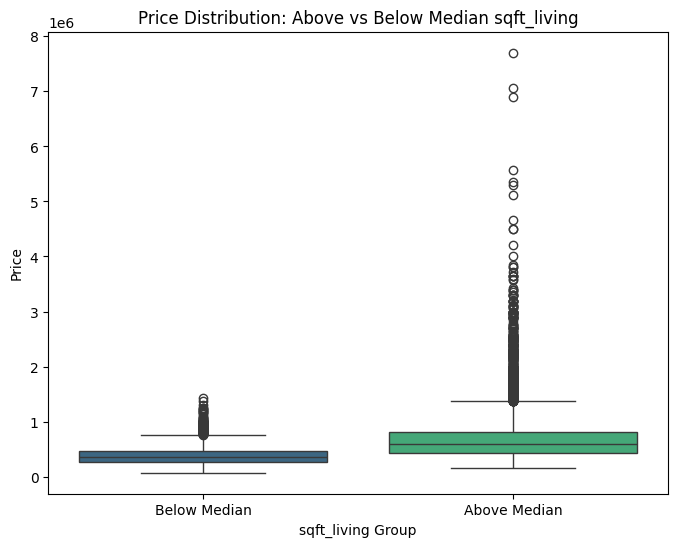

/tmp/ipykernel_12805/3149163933.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sqlalchemy, x='sqft_group', y='price', estimator='median', palette='viridis')


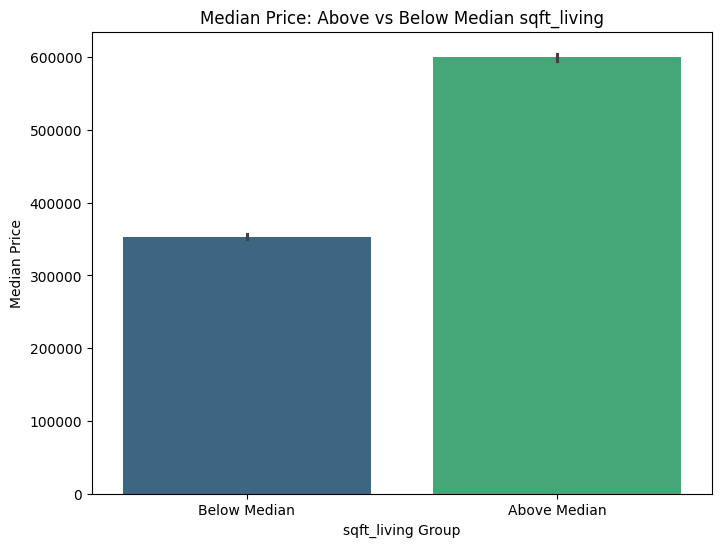

In [25]:
# Create a label column for the two groups
df_sqlalchemy['sqft_group'] = df_sqlalchemy['sqft_living'].apply(lambda x: 'Above Median' if x >= median_sqft else 'Below Median')

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_sqlalchemy, x='sqft_group', y='price', palette='viridis')
plt.title('Price Distribution: Above vs Below Median sqft_living')
plt.xlabel('sqft_living Group')
plt.ylabel('Price')
plt.show()

# Barplot (median price per group)
plt.figure(figsize=(8, 6))
sns.barplot(data=df_sqlalchemy, x='sqft_group', y='price', estimator='median', palette='viridis')
plt.title('Median Price: Above vs Below Median sqft_living')
plt.xlabel('sqft_living Group')
plt.ylabel('Median Price')
plt.show()

In [26]:
# issue 5
above_median_price = above_median['price'].median()
below_median_price = below_median['price'].median()
difference = above_median_price - below_median_price
pct_difference = (difference / below_median_price) * 100

print("=" * 50)
print("HYPOTHESIS 1 VERDICT")
print("=" * 50)
print(f"Median price (above median sqft_living): ${above_median_price:,.0f}")
print(f"Median price (below median sqft_living): ${below_median_price:,.0f}")
print(f"Difference:                              ${difference:,.0f}")
print(f"Percentage difference:                    {pct_difference:.1f}%")
print()
if above_median_price > below_median_price:
    print("✅ SUPPORTED: Houses with above-median sqft_living")
    print("   have a higher median price than those below median.")
else:
    print("❌ NOT SUPPORTED: No clear price advantage for")
    print("   houses with above-median sqft_living.")

HYPOTHESIS 1 VERDICT
Median price (above median sqft_living): $600,000
Median price (below median sqft_living): $353,000
Difference:                              $247,000
Percentage difference:                    70.0%

✅ SUPPORTED: Houses with above-median sqft_living
   have a higher median price than those below median.
